# Dog Breed Classification

## Importing Libraries

In [53]:
import tensorflow as tf
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [54]:
# CONFIGURATION

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15


## Load dataset

In [55]:
train_path = "/kaggle/input/datasets/miljan/stanford-dogs-dataset-traintest/cropped/train"
test_path = "/kaggle/input/datasets/miljan/stanford-dogs-dataset-traintest/cropped/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12000 files belonging to 120 classes.
Found 8580 files belonging to 120 classes.


In [56]:
# SAVE CLASS LABELS AFTER CLEANING

original_class_names = train_ds.class_names

class_names = [
    name.split("-",1)[1]
    for name in original_class_names
]

print("\nCleaned Labels:")
print(class_names)


os.makedirs(
    "saved_model",
    exist_ok=True
)


with open(
    "saved_model/labels.json",
    "w"
) as f:

    json.dump(
        class_names,
        f
    )


Cleaned Labels:
['Chihuahua', 'Japanese_spaniel', 'Maltese_dog', 'Pekinese', 'Shih-Tzu', 'Blenheim_spaniel', 'papillon', 'toy_terrier', 'Rhodesian_ridgeback', 'Afghan_hound', 'basset', 'beagle', 'bloodhound', 'bluetick', 'black-and-tan_coonhound', 'Walker_hound', 'English_foxhound', 'redbone', 'borzoi', 'Irish_wolfhound', 'Italian_greyhound', 'whippet', 'Ibizan_hound', 'Norwegian_elkhound', 'otterhound', 'Saluki', 'Scottish_deerhound', 'Weimaraner', 'Staffordshire_bullterrier', 'American_Staffordshire_terrier', 'Bedlington_terrier', 'Border_terrier', 'Kerry_blue_terrier', 'Irish_terrier', 'Norfolk_terrier', 'Norwich_terrier', 'Yorkshire_terrier', 'wire-haired_fox_terrier', 'Lakeland_terrier', 'Sealyham_terrier', 'Airedale', 'cairn', 'Australian_terrier', 'Dandie_Dinmont', 'Boston_bull', 'miniature_schnauzer', 'giant_schnauzer', 'standard_schnauzer', 'Scotch_terrier', 'Tibetan_terrier', 'silky_terrier', 'soft-coated_wheaten_terrier', 'West_Highland_white_terrier', 'Lhasa', 'flat-coated

In [57]:
# OPTIMIZE DATASET
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

## Build model : MobileNetV2

In [58]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(len(class_names),activation="softmax"
               )(x)

model = Model(
    inputs,
    outputs
)

## Compile Model

In [59]:
# MODEL COMPILATION
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_7 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,437,432 (9.30 MB)

 Trainable params: 179,448 (700.97 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train Model

In [60]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.5443 - loss: 1.8370 - val_accuracy: 0.7973 - val_loss: 0.6966
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7628 - loss: 0.7763 - val_accuracy: 0.8117 - val_loss: 0.6025
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8062 - loss: 0.6109 - val_accuracy: 0.8221 - val_loss: 0.5743
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8417 - loss: 0.5123 - val_accuracy: 0.8277 - val_loss: 0.5585
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8593 - loss: 0.4311 - val_accuracy: 0.8244 - val_loss: 0.5622
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8777 - loss: 0.3729 - val_accuracy: 0.8204 - val_loss: 0.5776
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8879 - loss: 0.3283 - val_accuracy: 0.8230 - val_loss: 0.5905
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9042 - loss: 0.2872 - 

## Save Model

In [61]:
# SAVE MODEL
model.save(
    "saved_model/dog_model.keras"
)

print("MODEL TRAINING COMPLETED")

MODEL TRAINING COMPLETED


## Evaluate Model

In [62]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [63]:
y_true=[]
y_pred=[]

for images,labels in test_ds:

    predictions = model.predict(images)

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━

Confusion Matrix Saved


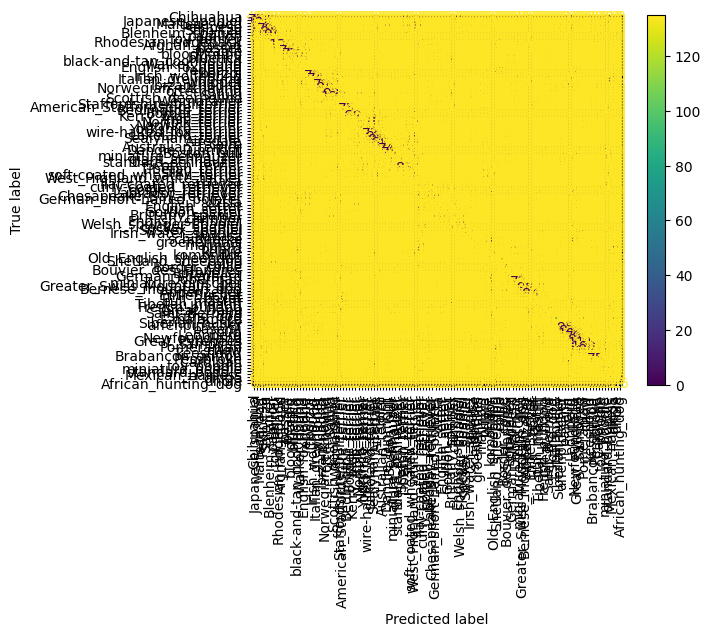

In [65]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_true,
    y_pred
)

display = ConfusionMatrixDisplay(
    cm,
    display_labels=class_names
)


display.plot(
    xticks_rotation=90
)


plt.savefig(
    "confusion_matrix.png"
)


print("Confusion Matrix Saved")

In [66]:
# PRECISION, RECALL AND F1 SCORE
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                precision    recall  f1-score   support

                     Chihuahua       0.64      0.87      0.74        52
              Japanese_spaniel       0.84      0.88      0.86        85
                   Maltese_dog       0.92      0.83      0.87       152
                      Pekinese       0.79      0.76      0.77        49
                      Shih-Tzu       0.71      0.69      0.70       114
              Blenheim_spaniel       0.93      0.95      0.94        88
                      papillon       0.88      0.95      0.91        96
                   toy_terrier       0.78      0.72      0.75        72
           Rhodesian_ridgeback       0.81      0.69      0.75        72
                  Afghan_hound       0.92      0.97      0.94       139
                        basset       0.80      0.85      0.83        75
                        beagle       0.86      0.80      0.83        95
                    bloodhound       0.88      0.83      0.85  

In [67]:
def validate_prediction(
    claimed_animal,
    claimed_category,
    predicted_category,
    confidence
):

    cleaned_claim = clean_label(
        claimed_category
    )


    cleaned_prediction = clean_label(
        predicted_category
    )


    match = (
        cleaned_claim 
        == 
        cleaned_prediction
    )


    if confidence < 60:

        decision="needs_review"


    elif match:

        decision="accept"


    else:

        decision="reject"



    return {

        "claimed_animal": claimed_animal,

        "claimed_category": claimed_category,

        "predicted_animal": "dog",

        "predicted_category": predicted_category,

        "match": match,

        "confidence": round(confidence,2),

        "decision": decision

    }

In [68]:
# TEST IMAGE PREDICTION
from PIL import Image


def predict_image(image_path, claimed_category):

    img = Image.open(
        image_path
    ).convert("RGB")


    img = img.resize(
        (224,224)
    )


    img_array = np.array(img)


    img_array = np.expand_dims(
        img_array,
        axis=0
    )


    prediction = model.predict(
        img_array
    )[0]


    index = np.argmax(
        prediction
    )


    predicted_category = class_names[index]


    confidence = float(
        prediction[index]*100
    )


    result = validate_prediction(
        "dog",
        claimed_category,
        predicted_category,
        confidence
    )


    return result


In [69]:

import os

for dirname, _, filenames in os.walk("/kaggle/input/datasets/miyashaikh/demotest"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/miyashaikh/demotest/LabradorRetriever.jpg
/kaggle/input/datasets/miyashaikh/demotest/Chihuahua.jpg
/kaggle/input/datasets/miyashaikh/demotest/GoldenRetriever.jpg


In [70]:
# Test 1
result1 = predict_image(
    "/kaggle/input/datasets/miyashaikh/demotest/LabradorRetriever.jpg", "Golden Retriever"
)

result1

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


{'claimed_animal': 'dog',
 'claimed_category': 'Golden Retriever',
 'predicted_animal': 'dog',
 'predicted_category': 'golden_retriever',
 'match': True,
 'confidence': 71.27,
 'decision': 'accept'}

In [71]:
# Test 2
result2 = predict_image(
    "/kaggle/input/datasets/miyashaikh/demotest/Chihuahua.jpg", "Chihuahua"
)

result2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


{'claimed_animal': 'dog',
 'claimed_category': 'Chihuahua',
 'predicted_animal': 'dog',
 'predicted_category': 'Chihuahua',
 'match': True,
 'confidence': 85.25,
 'decision': 'accept'}

In [72]:
# Test 3
result3 = predict_image(
    "/kaggle/input/datasets/miyashaikh/demotest/GoldenRetriever.jpg", "GoldenRetriever"
)

result3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


{'claimed_animal': 'dog',
 'claimed_category': 'GoldenRetriever',
 'predicted_animal': 'dog',
 'predicted_category': 'golden_retriever',
 'match': True,
 'confidence': 99.99,
 'decision': 'accept'}

In [73]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        print(os.path.join(root,file))

/kaggle/working/confusion_matrix.png
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/saved_model/labels.json
/kaggle/working/saved_model/dog_model.keras
